In [2]:
import os
import sys
path = os.getcwd()
while True:
    if 'utils.py' in os.listdir(path):
        if path not in sys.path:
            sys.path.append(path)
        break
    new_path = os.path.dirname(path)
    if new_path == path:
        upload_utils = files.upload()
        break
    path = new_path

import utils

/opt/anaconda3/envs/nlp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_Llama_3.1_8B_Instruct/Results/checkpoint_qnli_Llama_3.1_8B_Instruct_8bit_zero_shot.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_Llama_3.1_8B_Instruct/Results/checkpoint_qnli_Llama_3.1_8B_Instruct_8bit_few_shot_1_examples_entailment.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_Llama_3.1_8B_Instruct/Results/checkpoint_qnli_Llama_3.1_8B_Instruct_8bit_few_shot_1_examples_not_entailment.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_Llama_3.1_8B_Instruct/Results/checkpoint_qnli_Llama_3.1_8B_Instruct_8bit_few_shot_2_examples.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_Llama_3.1_8B_Instruct/Results/checkpoint_qnli_Llama_3.1_8B_Instruct_8bit_few_shot_3

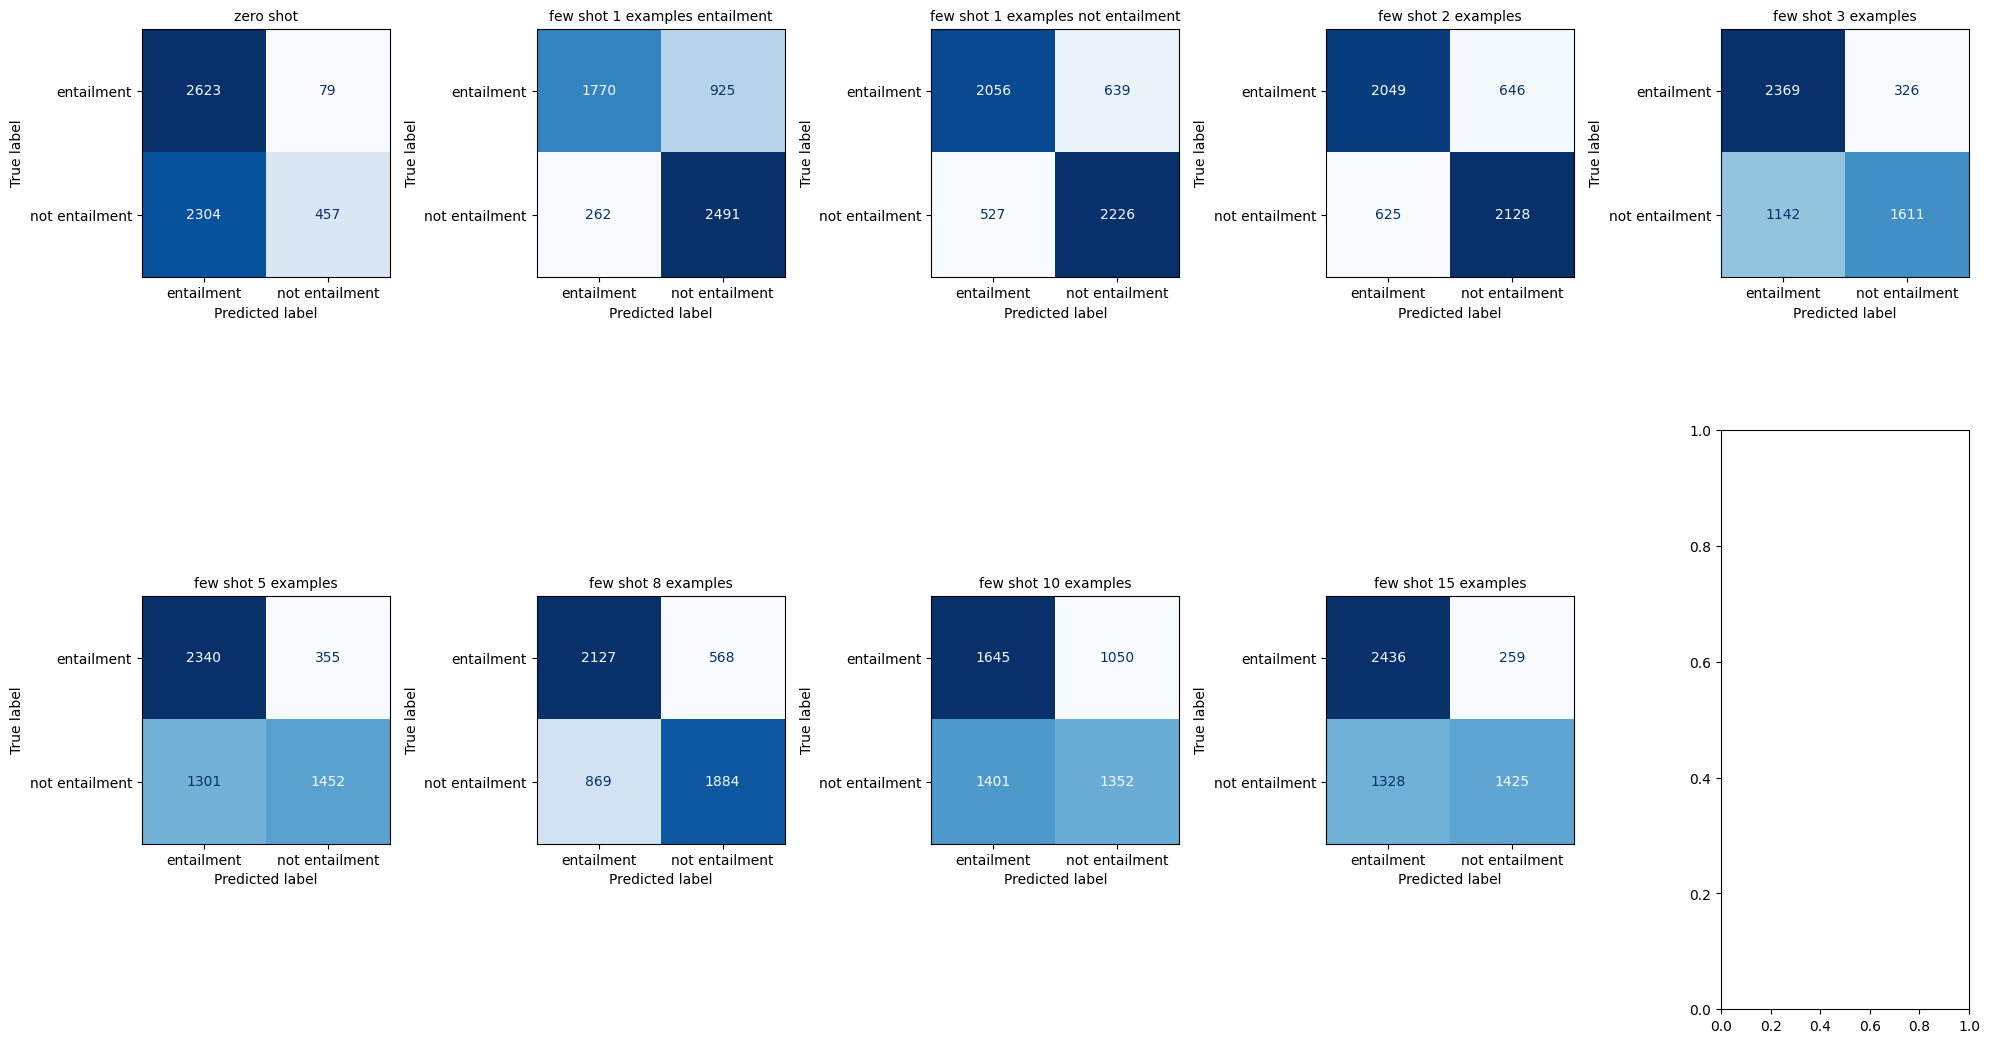

In [2]:
import matplotlib.pyplot as plt

training_modes = [
    'zero shot',
    'few shot 1 examples entailment',
    'few shot 1 examples not entailment',
    'few shot 2 examples',
    'few shot 3 examples',
    'few shot 5 examples',
    'few shot 8 examples',
    'few shot 10 examples',
    'few shot 15 examples'    
]

fig, axes = plt.subplots(2, 5, figsize=(20,12))
axes = axes.flatten()
accs, precisions, recalls, f1s, mccs, kappas = [], [], [], [], [], []

for idx, mode in enumerate(training_modes):
    global_params = {'dataset_type': 'qnli',
                'quantization': '8bit',
                'training_mode': mode,
                'model_id': 'meta-llama/Llama-3.1-8B-Instruct'}
   
    checkpoint_path = utils.create_checkpoint_path(params=global_params)
    predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)

    acc, precision, recall, f1, mcc, kappa = utils.get_metrics(
                                            predicted_labels=predicted_labels,
                                            gold_labels=gold_labels,
                                            params=global_params,
                                            ax=axes[idx]
                                            )   
    accs.append(round(acc, 4))
    precisions.append(round(precision, 4))
    recalls.append(round(recall, 4))
    f1s.append(round(f1, 4))
    mccs.append(round(mcc, 4))
    kappas.append(round(kappa, 4))

plt.tight_layout()
plt.show()

In [3]:
import pandas as pd
labels = [
    "0 examples",
    "1 example (entailment)",
    "1 example (not entailment)",
    "2 examples",
    "3 examples",
    "5 examples",
    "8 examples",
    "10 examples",
    "15 examples"
]

metrics_df = pd.DataFrame(
    {"Accuracy": accs,
     "Precision": precisions,
     "Recalls": recalls,
     "F1": f1s,
     "MCC": mccs,
     "Kappa": kappas},
     index= labels
)
metrics_df

,Accuracy,Precision,Recalls,F1,MCC,Kappa
0 examples,0.5638,0.6925,0.5681,0.4824,0.2291,0.1351
1 example (entailment),0.7821,0.8001,0.7808,0.7782,0.5806,0.5631
1 example (not entailment),0.7860,0.7865,0.7857,0.7858,0.5722,0.5717
2 examples,0.7667,0.7667,0.7666,0.7667,0.5333,0.5333
3 examples,0.7305,0.7532,0.7321,0.7252,0.4849,0.4627
5 examples,0.6960,0.7231,0.6978,0.6877,0.4202,0.3942
8 examples,0.7362,0.7391,0.7368,0.7357,0.4759,0.4730
10 examples,0.5501,0.5515,0.5507,0.5488,0.1022,0.1014
15 examples,0.7087,0.7467,0.7108,0.6983,0.4560,0.4198


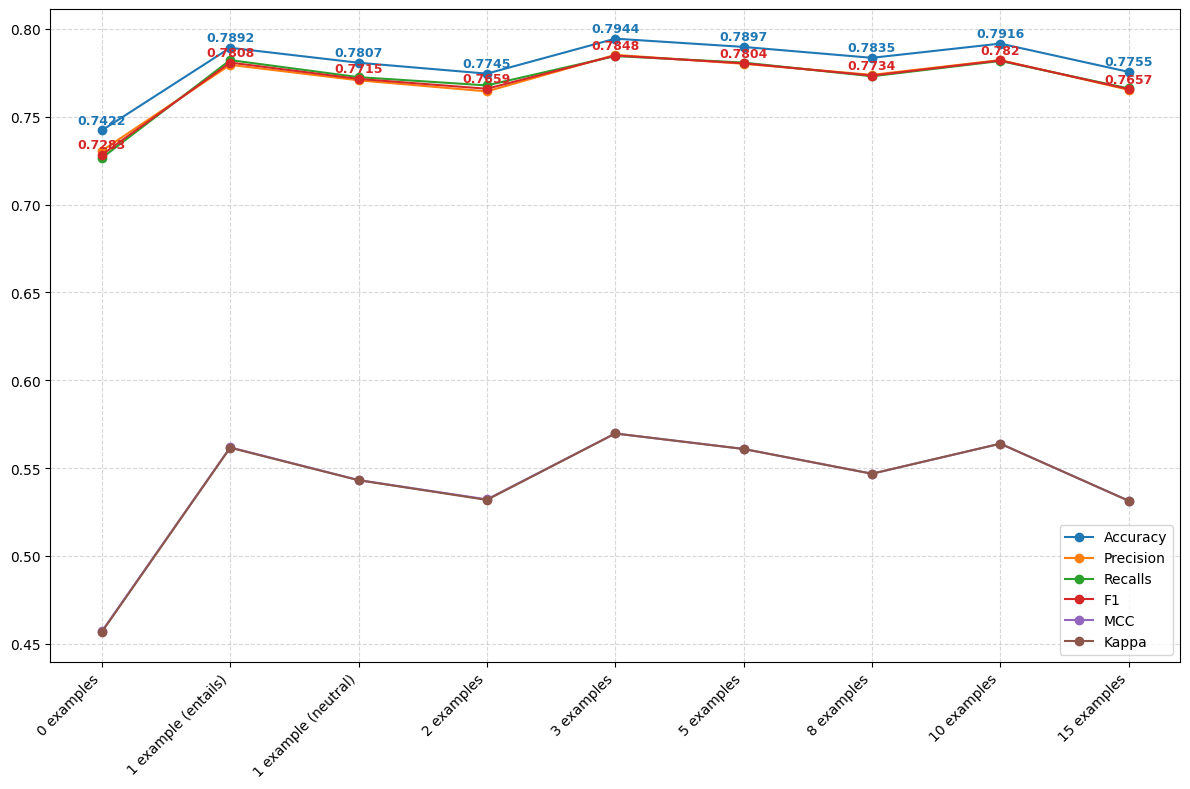

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

# plot all metrics
metrics_df.plot(kind='line', ax=ax, marker='o')

# set custom x-axis labels
ax.set_xticks(range(len(metrics_df.index)))
ax.set_xticklabels(metrics_df.index, rotation=45, ha='right')

# show grid
ax.grid(True, linestyle='--', alpha=0.5)

# annotate only Accuracy and F1
for metric in ["Accuracy", "F1"]:
    for x, y in enumerate(metrics_df[metric]):
        ax.text(x, y + 0.002, str(y), ha='center', va='bottom', fontsize=9, fontweight='bold', color=ax.get_lines()[list(metrics_df.columns).index(metric)].get_color())

plt.tight_layout()
plt.show()

Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_Llama_3.1_8B_Instruct/Results/checkpoint_qnli_Llama_3.1_8B_Instruct_8bit_zero_shot_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_Llama_3.1_8B_Instruct/Results/checkpoint_qnli_Llama_3.1_8B_Instruct_8bit_few_shot_1_examples_entailment_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_Llama_3.1_8B_Instruct/Results/checkpoint_qnli_Llama_3.1_8B_Instruct_8bit_few_shot_1_examples_not_entailment_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_Llama_3.1_8B_Instruct/Results/checkpoint_qnli_Llama_3.1_8B_Instruct_8bit_few_shot_2_examples_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_Llama_3.1_8B_Instruct/Resul

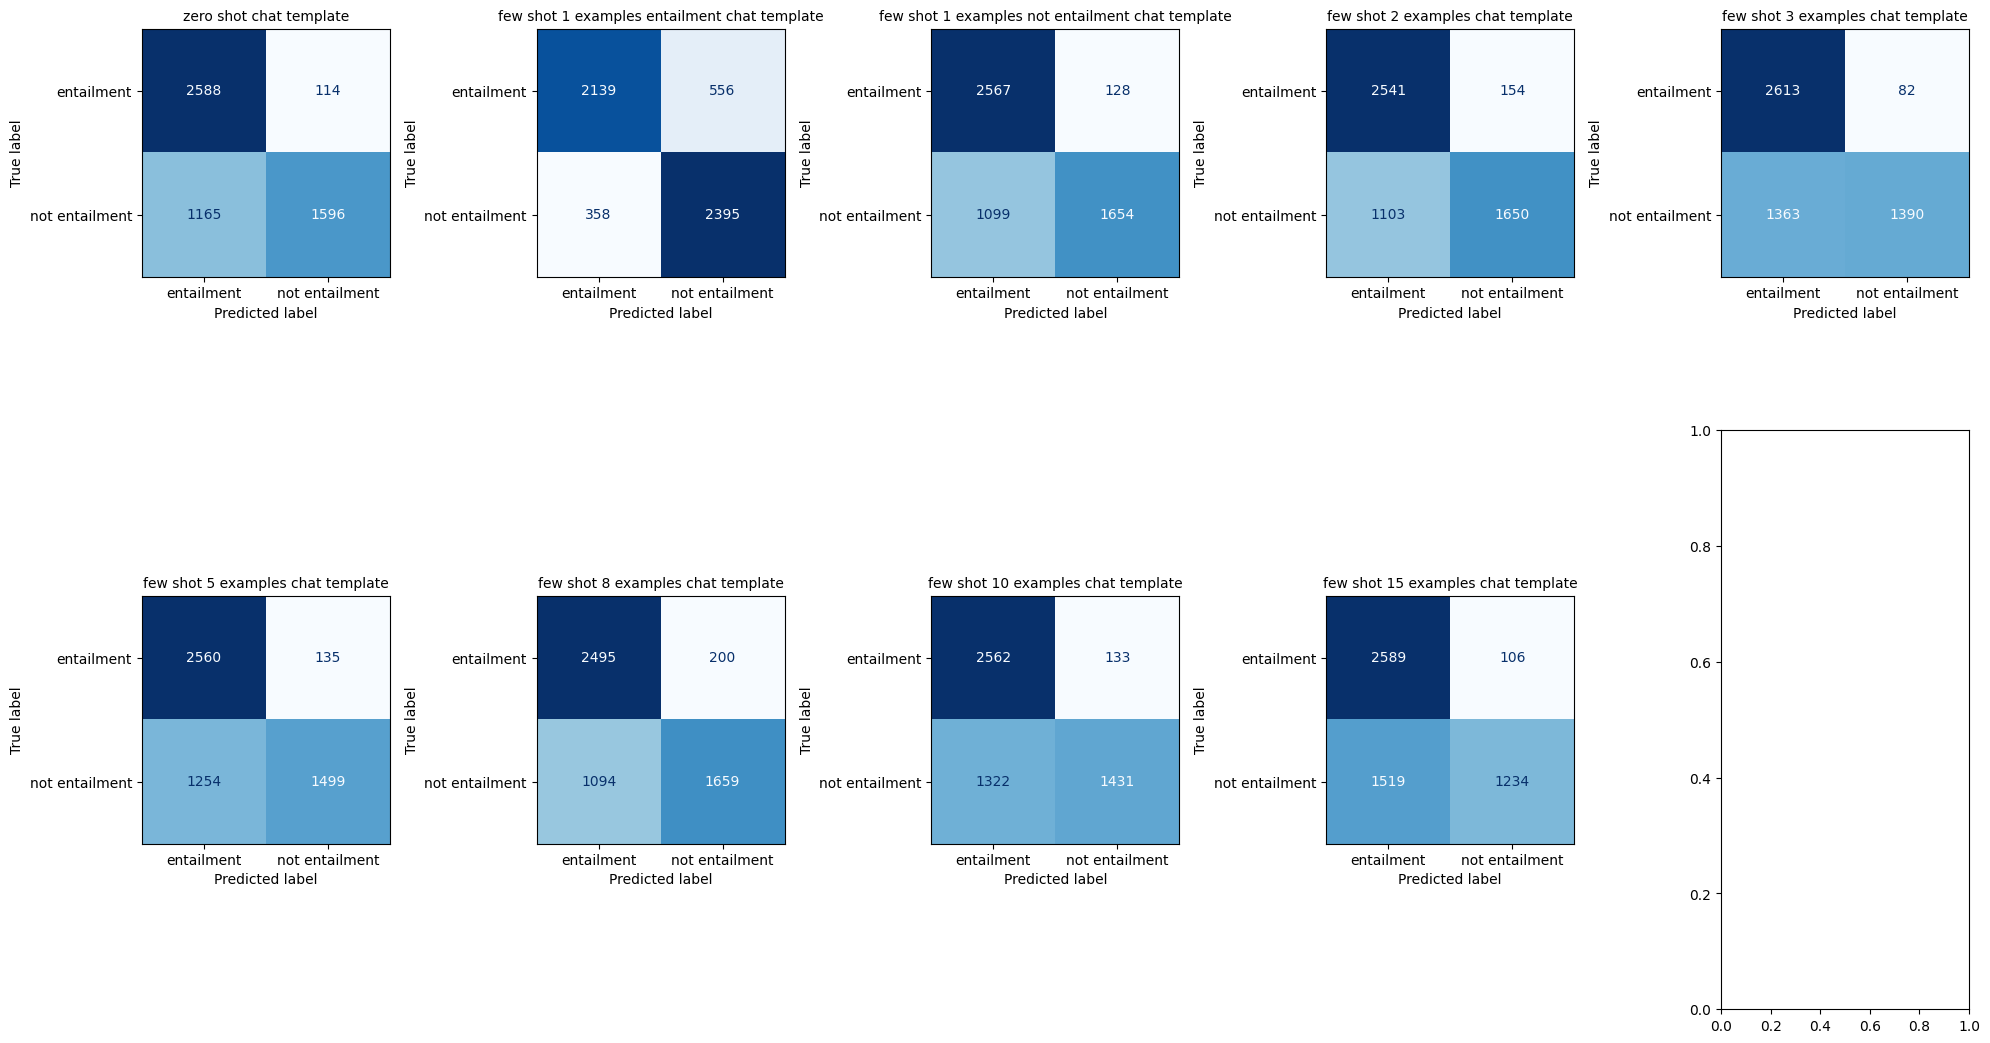

In [4]:
import matplotlib.pyplot as plt

training_modes = [
    'zero shot chat template',
    'few shot 1 examples entailment chat template',
    'few shot 1 examples not entailment chat template',
    'few shot 2 examples chat template',
    'few shot 3 examples chat template',
    'few shot 5 examples chat template',
    'few shot 8 examples chat template',
    'few shot 10 examples chat template',
    'few shot 15 examples chat template'    
]

fig, axes = plt.subplots(2, 5, figsize=(20,12))
axes = axes.flatten()
accs, precisions, recalls, f1s, mccs, kappas = [], [], [], [], [], []

for idx, mode in enumerate(training_modes):
    global_params = {'dataset_type': 'qnli',
                'quantization': '8bit',
                'training_mode': mode,
                'model_id': 'meta-llama/Llama-3.1-8B-Instruct'}
   
    checkpoint_path = utils.create_checkpoint_path(params=global_params)
    predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)

    acc, precision, recall, f1, mcc, kappa = utils.get_metrics(
                                            predicted_labels=predicted_labels,
                                            gold_labels=gold_labels,
                                            params=global_params,
                                            ax=axes[idx]
                                            )   
    accs.append(round(acc, 4))
    precisions.append(round(precision, 4))
    recalls.append(round(recall, 4))
    f1s.append(round(f1, 4))
    mccs.append(round(mcc, 4))
    kappas.append(round(kappa, 4))

plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
labels = [
    "0 examples",
    "1 example (entailment)",
    "1 example (not entailment)",
    "2 examples",
    "3 examples",
    "5 examples",
    "8 examples",
    "10 examples",
    "15 examples"
]

metrics_df_chat_template = pd.DataFrame(
    {"Accuracy": accs,
     "Precision": precisions,
     "Recalls": recalls,
     "F1": f1s,
     "MCC": mccs,
     "Kappa": kappas},
     index= labels
)
metrics_df_chat_template

,Accuracy,Precision,Recalls,F1,MCC,Kappa
0 examples,0.7659,0.8115,0.7679,0.7579,0.5778,0.5336
1 example (entailment),0.8322,0.8341,0.8318,0.8319,0.6659,0.6642
1 example (not entailment),0.7748,0.8142,0.7767,0.7683,0.5897,0.5512
2 examples,0.7693,0.8060,0.7711,0.7629,0.5760,0.5402
3 examples,0.7348,0.8007,0.7372,0.7207,0.5342,0.4721
5 examples,0.7450,0.7943,0.7472,0.7350,0.5394,0.4923
8 examples,0.7625,0.7938,0.7642,0.7568,0.5572,0.5266
10 examples,0.7329,0.7873,0.7352,0.7209,0.5199,0.4683
15 examples,0.7017,0.7756,0.7045,0.6821,0.4747,0.4067


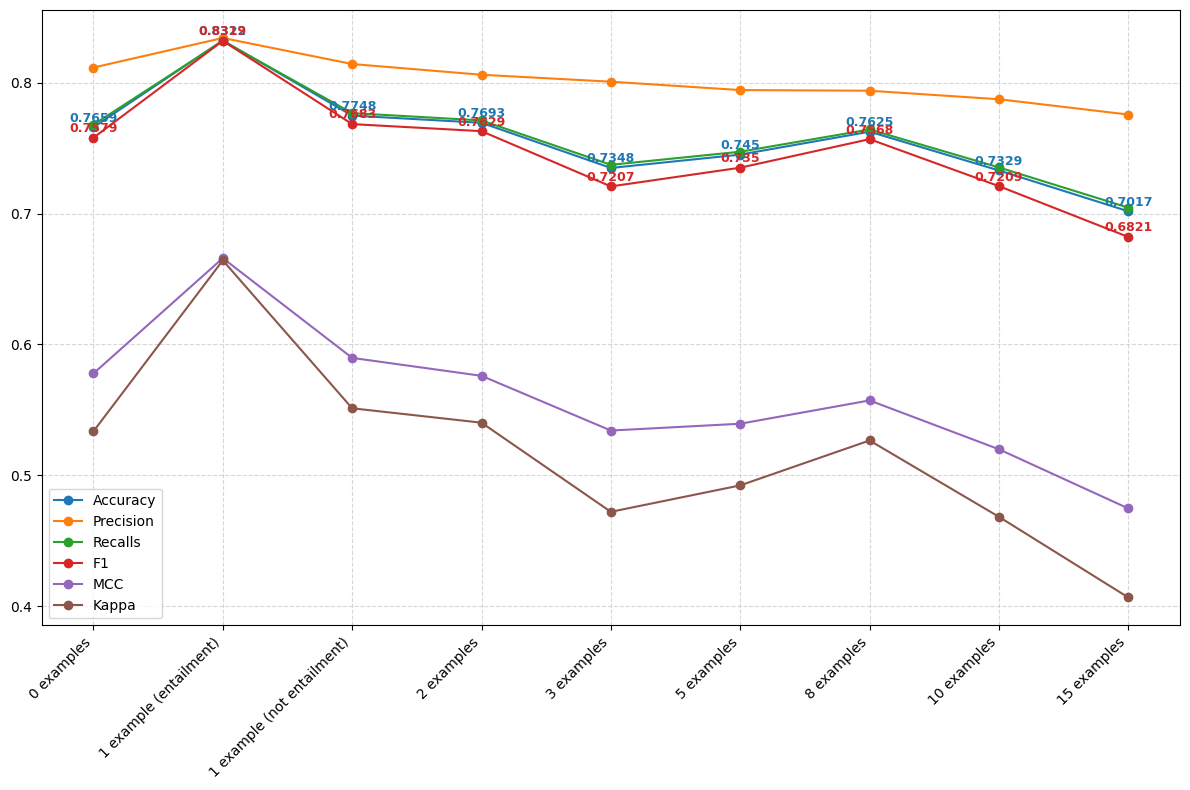

In [9]:
fig, ax = plt.subplots(figsize=(12, 8))

# plot all metrics
metrics_df_chat_template.plot(kind='line', ax=ax, marker='o')

# set custom x-axis labels
ax.set_xticks(range(len(metrics_df_chat_template.index)))
ax.set_xticklabels(metrics_df_chat_template.index, rotation=45, ha='right')

# show grid
ax.grid(True, linestyle='--', alpha=0.5)

# annotate only Accuracy and F1
for metric in ["Accuracy", "F1"]:
    for x, y in enumerate(metrics_df_chat_template[metric]):
        ax.text(x, y + 0.002, str(y), ha='center', va='bottom', fontsize=9, fontweight='bold', color=ax.get_lines()[list(metrics_df_chat_template.columns).index(metric)].get_color())

plt.tight_layout()
plt.show()